In [2]:
# Implementing this code should not have been done, but it is in the repo as it was
# used on the data  (it was a gross misinterpretation of "polarity correction")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load Doppler-corrected Stokes V profiles of each pixel
df = np.load("C:/DCU_final_year_project/doppler_corrected_profiles/ItoQUVcorrected_CBJTML_doppler_corrected_stokes_v.npy")


In [3]:
df.shape
# (182, 2555, 900)

(182, 2555, 900)

0.0040733060476592945
-0.0037816336003802485


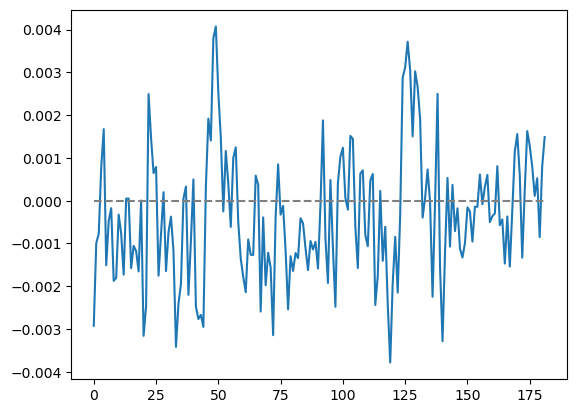

In [98]:
# Generate Stokes V plot at sample pixel
#y can be in range 0-2554, x can be 0-899
y_test, x_test = 0, 300

sample_plot = df[:, y_test, x_test]
plt.plot(sample_plot)
plt.hlines(0, 0, 181, linestyle = '--', color = 'gray')

# Find and show min and max values of Stokes V plot
max_value = np.nanmax(sample_plot)
min_value = np.nanmin(sample_plot)

print(max_value)
print(min_value)


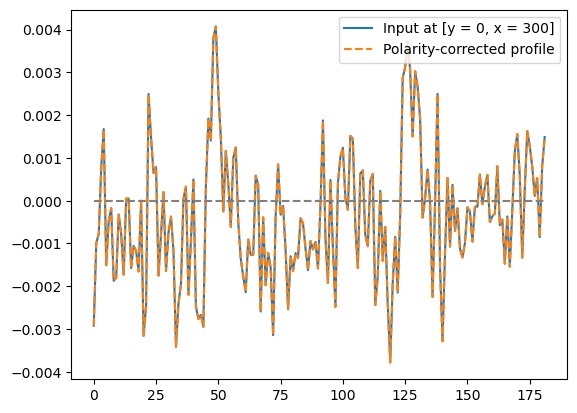

Original maximum point = 0.0040733060476592945
Original minimum point = -0.0037816336003802485


In [99]:
# Function to find whether largest magnitude absolute value is positive or negative
# and to flip the polarity of the profile if |min| > |max|
wavelengths = np.linspace(0, 181, num = 182)

def polarity_flip(arr):
    max_positive = np.nanmax(arr)
    max_negative = np.nanmin(arr)
    
    max_positive_abs = np.abs(max_positive)
    max_negative_abs = np.abs(max_negative)
    
    
    if max_negative_abs > max_positive_abs:
        arr = [i * -1 for i in arr]
    
    else:
        arr = arr
    
    return arr

# Run function for sample pixel given as input in the previous cell       
test_flip = polarity_flip(sample_plot)

#test_flip.shape

plt.plot(wavelengths, sample_plot, label='Input at [y = ' + str(y_test) + ', x = ' + str(x_test) + ']')
plt.plot(wavelengths, test_flip, label = 'Polarity-corrected profile', linestyle = '--')
plt.hlines(0, 0, 181, linestyle = '--', color = 'gray')
plt.legend()
plt.show()

print('Original maximum point = ' + str(np.nanmax(sample_plot)))     
print('Original minimum point = ' + str(np.nanmin(sample_plot)))


In [106]:
# Run through a for loop of the polarity flip function for each (y,x) pixel in the array

n_lambda, n_y, n_x = df.shape
corrected_polarity = np.empty_like(df, dtype = df.dtype)

for y in range(n_y):
    for x in range(n_x):
        
        #original_polarity = df[:, y, x]
        
        corrected_polarity[:, y, x] = polarity_flip(df[:, y, x])
    print(f"Processed y = {y+1}/{n_y}")

Processed y = 1/2555
Processed y = 2/2555
Processed y = 3/2555
Processed y = 4/2555
Processed y = 5/2555
Processed y = 6/2555
Processed y = 7/2555
Processed y = 8/2555
Processed y = 9/2555
Processed y = 10/2555
Processed y = 11/2555
Processed y = 12/2555
Processed y = 13/2555
Processed y = 14/2555
Processed y = 15/2555
Processed y = 16/2555
Processed y = 17/2555
Processed y = 18/2555
Processed y = 19/2555
Processed y = 20/2555
Processed y = 21/2555
Processed y = 22/2555
Processed y = 23/2555
Processed y = 24/2555
Processed y = 25/2555
Processed y = 26/2555
Processed y = 27/2555
Processed y = 28/2555
Processed y = 29/2555
Processed y = 30/2555
Processed y = 31/2555
Processed y = 32/2555
Processed y = 33/2555
Processed y = 34/2555
Processed y = 35/2555
Processed y = 36/2555
Processed y = 37/2555
Processed y = 38/2555
Processed y = 39/2555
Processed y = 40/2555
Processed y = 41/2555
Processed y = 42/2555
Processed y = 43/2555
Processed y = 44/2555
Processed y = 45/2555
Processed y = 46/25

Processed y = 363/2555
Processed y = 364/2555
Processed y = 365/2555
Processed y = 366/2555
Processed y = 367/2555
Processed y = 368/2555
Processed y = 369/2555
Processed y = 370/2555
Processed y = 371/2555
Processed y = 372/2555
Processed y = 373/2555
Processed y = 374/2555
Processed y = 375/2555
Processed y = 376/2555
Processed y = 377/2555
Processed y = 378/2555
Processed y = 379/2555
Processed y = 380/2555
Processed y = 381/2555
Processed y = 382/2555
Processed y = 383/2555
Processed y = 384/2555
Processed y = 385/2555
Processed y = 386/2555
Processed y = 387/2555
Processed y = 388/2555
Processed y = 389/2555
Processed y = 390/2555
Processed y = 391/2555
Processed y = 392/2555
Processed y = 393/2555
Processed y = 394/2555
Processed y = 395/2555
Processed y = 396/2555
Processed y = 397/2555
Processed y = 398/2555
Processed y = 399/2555
Processed y = 400/2555
Processed y = 401/2555
Processed y = 402/2555
Processed y = 403/2555
Processed y = 404/2555
Processed y = 405/2555
Processed y

Processed y = 723/2555
Processed y = 724/2555
Processed y = 725/2555
Processed y = 726/2555
Processed y = 727/2555
Processed y = 728/2555
Processed y = 729/2555
Processed y = 730/2555
Processed y = 731/2555
Processed y = 732/2555
Processed y = 733/2555
Processed y = 734/2555
Processed y = 735/2555
Processed y = 736/2555
Processed y = 737/2555
Processed y = 738/2555
Processed y = 739/2555
Processed y = 740/2555
Processed y = 741/2555
Processed y = 742/2555
Processed y = 743/2555
Processed y = 744/2555
Processed y = 745/2555
Processed y = 746/2555
Processed y = 747/2555
Processed y = 748/2555
Processed y = 749/2555
Processed y = 750/2555
Processed y = 751/2555
Processed y = 752/2555
Processed y = 753/2555
Processed y = 754/2555
Processed y = 755/2555
Processed y = 756/2555
Processed y = 757/2555
Processed y = 758/2555
Processed y = 759/2555
Processed y = 760/2555
Processed y = 761/2555
Processed y = 762/2555
Processed y = 763/2555
Processed y = 764/2555
Processed y = 765/2555
Processed y

Processed y = 1079/2555
Processed y = 1080/2555
Processed y = 1081/2555
Processed y = 1082/2555
Processed y = 1083/2555
Processed y = 1084/2555
Processed y = 1085/2555
Processed y = 1086/2555
Processed y = 1087/2555
Processed y = 1088/2555
Processed y = 1089/2555
Processed y = 1090/2555
Processed y = 1091/2555
Processed y = 1092/2555
Processed y = 1093/2555
Processed y = 1094/2555
Processed y = 1095/2555
Processed y = 1096/2555
Processed y = 1097/2555
Processed y = 1098/2555
Processed y = 1099/2555
Processed y = 1100/2555
Processed y = 1101/2555
Processed y = 1102/2555
Processed y = 1103/2555
Processed y = 1104/2555
Processed y = 1105/2555
Processed y = 1106/2555
Processed y = 1107/2555
Processed y = 1108/2555
Processed y = 1109/2555
Processed y = 1110/2555
Processed y = 1111/2555
Processed y = 1112/2555
Processed y = 1113/2555
Processed y = 1114/2555
Processed y = 1115/2555
Processed y = 1116/2555
Processed y = 1117/2555
Processed y = 1118/2555
Processed y = 1119/2555
Processed y = 11

Processed y = 1421/2555
Processed y = 1422/2555
Processed y = 1423/2555
Processed y = 1424/2555
Processed y = 1425/2555
Processed y = 1426/2555
Processed y = 1427/2555
Processed y = 1428/2555
Processed y = 1429/2555
Processed y = 1430/2555
Processed y = 1431/2555
Processed y = 1432/2555
Processed y = 1433/2555
Processed y = 1434/2555
Processed y = 1435/2555
Processed y = 1436/2555
Processed y = 1437/2555
Processed y = 1438/2555
Processed y = 1439/2555
Processed y = 1440/2555
Processed y = 1441/2555
Processed y = 1442/2555
Processed y = 1443/2555
Processed y = 1444/2555
Processed y = 1445/2555
Processed y = 1446/2555
Processed y = 1447/2555
Processed y = 1448/2555
Processed y = 1449/2555
Processed y = 1450/2555
Processed y = 1451/2555
Processed y = 1452/2555
Processed y = 1453/2555
Processed y = 1454/2555
Processed y = 1455/2555
Processed y = 1456/2555
Processed y = 1457/2555
Processed y = 1458/2555
Processed y = 1459/2555
Processed y = 1460/2555
Processed y = 1461/2555
Processed y = 14

Processed y = 1763/2555
Processed y = 1764/2555
Processed y = 1765/2555
Processed y = 1766/2555
Processed y = 1767/2555
Processed y = 1768/2555
Processed y = 1769/2555
Processed y = 1770/2555
Processed y = 1771/2555
Processed y = 1772/2555
Processed y = 1773/2555
Processed y = 1774/2555
Processed y = 1775/2555
Processed y = 1776/2555
Processed y = 1777/2555
Processed y = 1778/2555
Processed y = 1779/2555
Processed y = 1780/2555
Processed y = 1781/2555
Processed y = 1782/2555
Processed y = 1783/2555
Processed y = 1784/2555
Processed y = 1785/2555
Processed y = 1786/2555
Processed y = 1787/2555
Processed y = 1788/2555
Processed y = 1789/2555
Processed y = 1790/2555
Processed y = 1791/2555
Processed y = 1792/2555
Processed y = 1793/2555
Processed y = 1794/2555
Processed y = 1795/2555
Processed y = 1796/2555
Processed y = 1797/2555
Processed y = 1798/2555
Processed y = 1799/2555
Processed y = 1800/2555
Processed y = 1801/2555
Processed y = 1802/2555
Processed y = 1803/2555
Processed y = 18

Processed y = 2106/2555
Processed y = 2107/2555
Processed y = 2108/2555
Processed y = 2109/2555
Processed y = 2110/2555
Processed y = 2111/2555
Processed y = 2112/2555
Processed y = 2113/2555
Processed y = 2114/2555
Processed y = 2115/2555
Processed y = 2116/2555
Processed y = 2117/2555
Processed y = 2118/2555
Processed y = 2119/2555
Processed y = 2120/2555
Processed y = 2121/2555
Processed y = 2122/2555
Processed y = 2123/2555
Processed y = 2124/2555
Processed y = 2125/2555
Processed y = 2126/2555
Processed y = 2127/2555
Processed y = 2128/2555
Processed y = 2129/2555
Processed y = 2130/2555
Processed y = 2131/2555
Processed y = 2132/2555
Processed y = 2133/2555
Processed y = 2134/2555
Processed y = 2135/2555
Processed y = 2136/2555
Processed y = 2137/2555
Processed y = 2138/2555
Processed y = 2139/2555
Processed y = 2140/2555
Processed y = 2141/2555
Processed y = 2142/2555
Processed y = 2143/2555
Processed y = 2144/2555
Processed y = 2145/2555
Processed y = 2146/2555
Processed y = 21

Processed y = 2450/2555
Processed y = 2451/2555
Processed y = 2452/2555
Processed y = 2453/2555
Processed y = 2454/2555
Processed y = 2455/2555
Processed y = 2456/2555
Processed y = 2457/2555
Processed y = 2458/2555
Processed y = 2459/2555
Processed y = 2460/2555
Processed y = 2461/2555
Processed y = 2462/2555
Processed y = 2463/2555
Processed y = 2464/2555
Processed y = 2465/2555
Processed y = 2466/2555
Processed y = 2467/2555
Processed y = 2468/2555
Processed y = 2469/2555
Processed y = 2470/2555
Processed y = 2471/2555
Processed y = 2472/2555
Processed y = 2473/2555
Processed y = 2474/2555
Processed y = 2475/2555
Processed y = 2476/2555
Processed y = 2477/2555
Processed y = 2478/2555
Processed y = 2479/2555
Processed y = 2480/2555
Processed y = 2481/2555
Processed y = 2482/2555
Processed y = 2483/2555
Processed y = 2484/2555
Processed y = 2485/2555
Processed y = 2486/2555
Processed y = 2487/2555
Processed y = 2488/2555
Processed y = 2489/2555
Processed y = 2490/2555
Processed y = 24

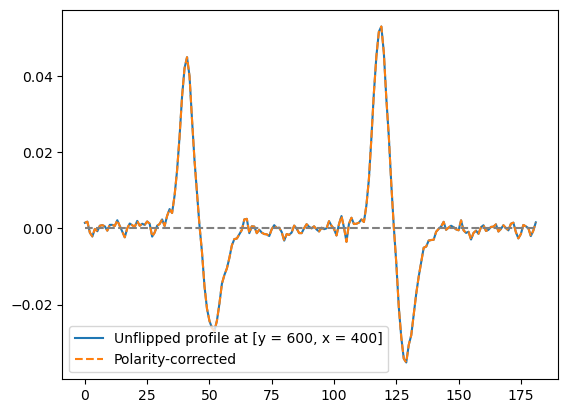

Original maximum point = 0.052980204890281414
Original minimum point = -0.03517002438303654


In [113]:
y_test, x_test = 600, 400

unflipped = df[:, y_test, x_test]
flip_checked = corrected_polarity[:, y_test, x_test]

plt.plot(wavelengths, unflipped, label='Unflipped profile at [y = ' + str(y_test) + ', x = ' + str(x_test) + ']')
plt.plot(wavelengths, flip_checked, linestyle='--', label='Polarity-corrected')
plt.hlines(0, 0, 181, linestyle = '--', color = 'gray')


plt.legend()
plt.show()
flip_checked.shape

print('Original maximum point = ' + str(np.nanmax(df[:, y_test, x_test])))     
print('Original minimum point = ' + str(np.nanmin(df[:, y_test, x_test])))


In [114]:
#np.save('C:/DCU_final_year_project/polarity_correction/ItoQUVcorrected_CBJTML_polarity_corrected', corrected_polarity)